In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
import torch
import torchaudio
import torchaudio.transforms
import random
import itertools

In [2]:
SR = 16000

In [3]:
def random_room_dimensions():
    x = random.uniform(4, 10)
    y = random.uniform(4, 10)
    z = random.uniform(2.5, 5)
    return np.array([x, y, z])

def random_head_position(room_dim, rdtw=0.125):
    rdx, rdy, _ = room_dim
    x = random.uniform(rdtw*rdx, (1-rdtw)*rdx)
    y = random.uniform(rdtw*rdy, (1-rdtw)*rdy)
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def random_head_angle():
    return random.uniform(0, 2*np.pi)

def random_mouth_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(-0.01, 0.01)
    rdy = random.uniform(0.11, 0.15)
    rdz = random.uniform(-0.04, -0.02)
    x = hpx + rdx*np.cos(head_ang) - rdy*np.sin(head_ang)
    y = hpy + rdx*np.sin(head_ang) + rdy*np.cos(head_ang)
    z = hpz + rdz
    return np.array([x, y, z])

def random_ears_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(0.08, 0.09)
    ear_center_l = np.array([hpx - rdx*np.cos(head_ang), hpy - rdx*np.sin(head_ang), hpz])
    ear_center_r = np.array([hpx + rdx*np.cos(head_ang), hpy + rdx*np.sin(head_ang), hpz])
    return np.array([ear_center_l, ear_center_r])

def define_mics_position(ears_pos):
    ear_center_l, ear_center_r = ears_pos
    lex, ley, lez = ear_center_l
    rex, rey, rez = ear_center_r
    mic_l_1 = np.array([lex, ley, lez - 0.01])
    # mic_l_2 = np.array([lex, ley, lez + 0.01])    
    mic_r_1 = np.array([rex, rey, rez - 0.01])
    # mic_r_2 = np.array([rex, rey, rez + 0.01])
    return np.array([mic_l_1, mic_r_1])
    # return np.array([mic_l_1, mic_l_2, mic_r_1, mic_r_2])

def random_distractor_position(room_dim, head_pos, rdtw=0.125):
    rdx, rdy, _ = room_dim
    hpx, hpy, _ = head_pos
    angle = random.uniform(0, 2*np.pi)

    dx = np.cos(angle)*1
    if dx > 0:
        x_min = hpx + dx
        x_max = (1-rdtw)*rdx
        if x_min > x_max:
            x_min = rdtw*rdx
            x_max = hpx - dx     
    else:
        x_min = rdtw*rdx
        x_max = hpx + dx
        if x_min > x_max:
            x_min = hpx - dx
            x_max = (1-rdtw)*rdx
    x = random.uniform(x_min, x_max)

    dy = np.sin(angle)*1
    if dy > 0:
        y_min = hpy + dy
        y_max = (1-rdtw)*rdy
        if y_min > y_max:
            y_min = rdtw*rdy
            y_max = hpy - dy
    else:
        y_min = rdtw*rdy
        y_max = hpy + dy
        if y_min > y_max:
            y_min = hpy - dy
            y_max = (1-rdtw)*rdy
    y = random.uniform(y_min, y_max)
    
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def random_snr(a=-5, b=5):
    return random.uniform(a, b)

def random_rt60(room_dim):
    v = np.prod(room_dim)
    s = 2 * np.sum([l1 * l2 for l1, l2 in itertools.combinations(room_dim, 2)])
    c = pra.parameters._constants_default['c']
    sc = 24
    a = v*sc*np.log(10)/(c*s)
    return random.uniform(a, 1.0)

def random_diffuse_noise_position(room_dim, num_sources=12):
    rdx, rdy, rdz = room_dim
    return [np.array([random.uniform(0, rdx), random.uniform(0, rdy), random.uniform(0, rdz)]) for _ in range(num_sources)]


## CREATE ROOM

In [4]:
room_dim = random_room_dimensions()
head_pos = random_head_position(room_dim)
head_ang = random_head_angle()
ears_pos = random_ears_position(head_pos, head_ang)
mics_pos = define_mics_position(ears_pos)
mouth_pos = random_mouth_position(head_pos,  head_ang)
distractor_pos = random_distractor_position(room_dim, head_pos)

In [5]:
noise_pos = random_diffuse_noise_position(room_dim, num_sources=24)

In [6]:
is_anechoic = True

# Create shoebox room.
if is_anechoic:
    e_absorption, max_order = 1.0, 0
else:
    rt60 = random_rt60(room_dim)
    e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)
room = pra.ShoeBox(room_dim, fs=SR, materials=pra.Material(e_absorption), max_order=max_order)

## LOAD AUDIO

In [7]:
clean_wav = torchaudio.utils.download_asset("tutorial-assets/mvdr/clean_speech.wav")
noise_wav = torchaudio.utils.download_asset("tutorial-assets/mvdr/noise.wav")
signal_clean, sr_clean = torchaudio.load(clean_wav)
signal_noise, sr_noise = torchaudio.load(noise_wav)

In [8]:
example_path = r"database\WHAM\tr\01aa010b_0.97482_209a010p_-0.97482.wav"
signal_noise, sr = torchaudio.load(example_path)

In [1]:
signal_noise

NameError: name 'signal_noise' is not defined

In [10]:
# Apply desired SNR
signal_clean = signal_clean[0].numpy()
signal_noise = signal_noise[0].numpy()
signal_clean = signal_clean / np.max(np.abs(signal_clean))  # Normalize
signal_noise = signal_noise / np.max(np.abs(signal_noise))  # Normalize
snr = 6
signal_noise = signal_noise * np.power(10, -snr/20)

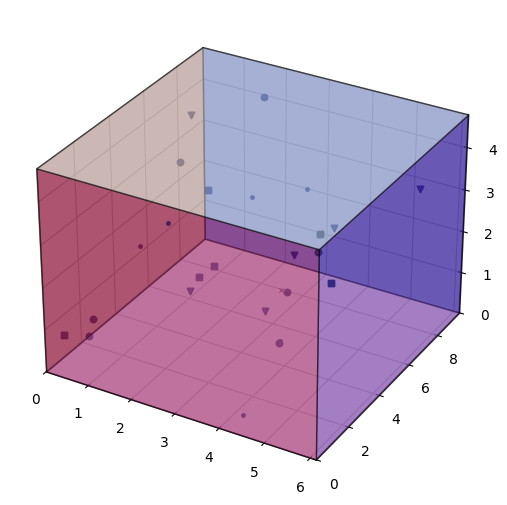

In [11]:
room.add_source(mouth_pos, signal=signal_clean, delay=0.0)
room.add_microphone_array(ears_pos.T)
# room.add_source(distractor_pos, signal=signal_noise, delay=0.0)
# room.plot();

# room2d = pra.ShoeBox(room_dim[0:2], fs=16000)
# room2d.add_source(mouth_pos[0:2])
# room2d.add_microphone_array(mics_pos.T[0:2])
# room2d.add_source(distractor_pos[0:2])
# room2d.plot();

for pos in noise_pos:
    room.add_source(pos, signal=signal_noise, delay=0.0)
room.plot();

## SIMULATE

In [12]:
room.simulate()

In [13]:
signal_mixed = room.mic_array.signals
# Normalize
signal_mixed = signal_mixed / np.max(np.abs(signal_mixed))

In [14]:
mix = torch.from_numpy(signal_mixed).to(torch.float32)

In [15]:
# Save signal
torchaudio.save("out/mixed_noise.wav", mix, SR)